Transition Matrix P:
 [[4.57346325e-01 1.95730342e-01 5.40467766e-02 9.21977835e-03
  9.46513139e-04]
 [1.68814325e-01 3.89090818e-01 3.15862544e-01 9.00965180e-02
  8.91562754e-03]
 [5.03440099e-02 2.42068273e-01 4.07769901e-01 2.42068273e-01
  5.03440099e-02]
 [8.91562754e-03 9.00965180e-02 3.15862544e-01 3.89090818e-01
  1.68814325e-01]
 [1.47212793e-05 3.04150819e-04 3.70276667e-03 2.69160176e-02
  1.19331402e-01]]
Simulated z_t:
 [-2.14242853 -1.07121426 -2.14242853 ... -1.07121426  0.
  1.07121426]


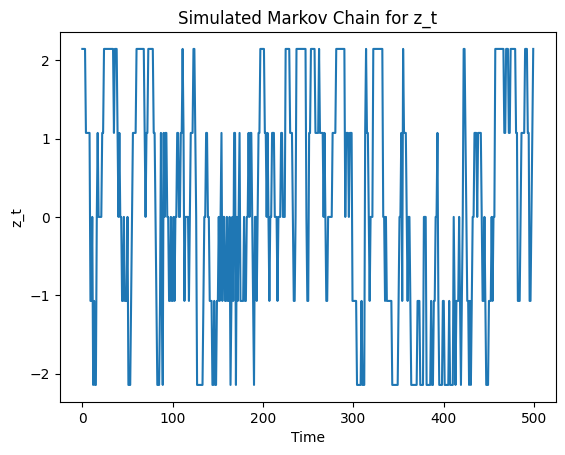

Mean of simulation: 0.26994599459891977
Standard deviation of simulation : 1.4642742775859994
Autocorrelation of simulation (lag 1): 0.8120272745264526
Theoretical Mean: 0
Theoretical Standard Deviation: 0.51
Theoretical Autocorrelation (lag 1): 0.7


In [35]:
import numpy as np
from numpy import sqrt
from scipy.stats import norm
import matplotlib.pyplot as plt

# Parameters 
# Ar(1) process z_t+1 = rho*z_t + (1- rho^2) epsilon_t+1 where epsilon ~ N(0,1)
rho = 0.7
m= 3
N = 5
T = 2000 
mean_z = 0
sigma_epsilon = 1
sigma_z = (1-rho**2)

# Tauchen method 
# Creating state space for (slide 28)
Z_N = m * sqrt(sigma_z)
Z_1 = - Z_N
d = (Z_N - Z_1) / (N - 1)
z_grid = np.linspace(Z_1, Z_N, N)

# Transition matrix (slide 29)
P = np.zeros((N, N))
P_i1 = norm.cdf((z_grid[0] - rho * z_grid + d / 2) / sigma_epsilon) # First row
P_iN = 1 - norm.cdf((z_grid[-1] - rho * z_grid + d / 2) / sigma_epsilon) # Last row
P_ij = np.zeros((N-2, N)) # Middle rows 
for i in range(1, N-1):
    for j in range(N):
        P_ij[i-1, j] = norm.cdf((z_grid[j] - rho * z_grid[i] + d / 2) / sigma_epsilon) - norm.cdf((z_grid[j] - rho * z_grid[i] - d / 2) / sigma_epsilon)

P[0, :] = P_i1
P[-1, :] = P_iN
P[1:-1, :] = P_ij
print("Transition Matrix P:\n", P)
P = P / P.sum(axis=1, keepdims=True) # Normalize rows to sum to 1

# Simulate Markov Chain 
z_sim = np.zeros(T)
z_sim[0] = Z_1  # Start at the lowest state
cdf = np.cumsum(P, axis=1)
cdf[:, -1] = 1.0

z_sim = np.empty(T)
idx = 0  # 0..N-1; e.g., 0 for lowest state
z_sim[0] = z_grid[idx]

u = np.random.rand(T-1)  # in [0,1)
for t in range(1, T):
    idx = np.searchsorted(cdf[idx], u[t-1], side="right")
    z_sim[t] = z_grid[idx]
print("Simulated z_t:\n", z_sim)

# Discard first 500 observations 
z_sim = z_sim[500:]

# Plot the simulated series
plt.plot(z_sim[:500]) #Only first 500 for better visibility
plt.title('Simulated Markov Chain for z_t')
plt.xlabel('Time')
plt.ylabel('z_t')
plt.show()
 
# Compute statistics for the simulated series
mean_z_sim = np.mean(z_sim)
std_z_sim = np.std(z_sim)
autocorr_z_sim = np.corrcoef(z_sim[:-1], z_sim[1:])[0, 1]

print("Mean of simulation:", mean_z_sim)
print("Standard deviation of simulation :", std_z_sim)
print("Autocorrelation of simulation (lag 1):", autocorr_z_sim)

# Theoretical moments (see slide 31)
theoretical_mean = mean_z
theoretical_var = (1-rho**2)**2
theoretical_corr = rho 

print("Theoretical Mean:", theoretical_mean)
print("Theoretical Standard Deviation:", sqrt(theoretical_var))
print("Theoretical Autocorrelation (lag 1):", theoretical_corr)





Rouwenhorst Transition Matrix P:
 [[6.52507812e-02 4.60593750e-02 1.21921875e-02 1.43437500e-03
  6.32812500e-05]
 [4.60593750e-02 2.85387500e-01 1.42481250e-01 2.46375000e-02
  1.43437500e-03]
 [1.21921875e-02 1.42481250e-01 4.40653125e-01 1.42481250e-01
  1.21921875e-02]
 [1.43437500e-03 2.46375000e-02 1.42481250e-01 2.85387500e-01
  4.60593750e-02]
 [6.32812500e-05 1.43437500e-03 1.21921875e-02 4.60593750e-02
  6.52507812e-02]]
Simulated z_t (Rouwenhorst):
 [-1.42828569  0.         -0.71414284 ...  0.71414284 -0.71414284
 -0.71414284]


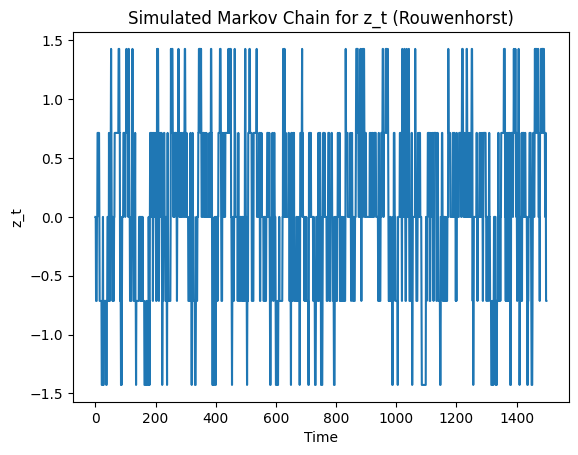

Mean of simulation (Rouwenhorst): 0.027613523257032393
Standard deviation of simulation (Rouwenhorst): 0.7202482164735525
Autocorrelation of simulation (lag 1) (Rouwenhorst): 0.7033211303933754


In [ ]:
# Rouwenhorst method 
# here sgima_e =1
std_Z = sqrt(1-rho**2)

# Construct markov chain
def rouwenhorst(N, rho, sigma_epsilon, std_Z):
    p = (1 + rho) / 2 #Becasue zero mean (see slide 38)
    q = p
    s = (1-p) / (2-(p+q))
    psi = sqrt(N-1) * std_Z #See slide 37-39 how to compute
    
    # Initial transition matrix for N=2 #Slide 36
    P = np.array([[p, 1 - p],
                  [1 - q, q]])
    
    # Recursive construction for N>2 #Slide 36
    for n in range(3, N + 1):
        P_new = np.zeros((n, n))
        P_new[:-1, :-1] += p * P
        P_new[:-1, 1:] += (1 - p) * P
        P_new[1:, :-1] += (1 - q) * P
        P_new[1:, 1:] += q * P
        P = P_new / 2
    
    # State space
    z_grid = np.linspace(-psi, psi, N)
    
    return p, s,z_grid, P
 
p, s, z_grid_r, P_r = rouwenhorst(N, rho, sigma_epsilon, std_Z)

print("Rouwenhorst Transition Matrix P:\n", P_r)
P_r = P_r / P_r.sum(axis=1, keepdims=True) #Nromalize 

# Simulate Markov Chain using Rouwenhorst method
z_sim_r = np.zeros(T)
z_sim_r[0] = Z_1  # Start at the lowest state
cdf_r = np.cumsum(P_r, axis=1)
cdf_r[:, -1] = 1.0
z_sim_r = np.empty(T)
idx = 0

z_sim_r[0] = z_grid_r[idx]
u_r = np.random.rand(T-1)  # in [0,1)
for t in range(1, T):
    idx = np.searchsorted(cdf_r[idx], u_r[t-1], side="right")
    z_sim_r[t] = z_grid_r[idx]
print("Simulated z_t (Rouwenhorst):\n", z_sim_r)

# Discard first 500 observations
z_sim_r = z_sim_r[500:]

# Plot the simulated series
plt.plot(z_sim_r)
plt.title('Simulated Markov Chain for z_t (Rouwenhorst)')
plt.xlabel('Time')
plt.ylabel('z_t')
plt.show()

# Compute statistics for the simulated series
mean_z_sim_r = np.mean(z_sim_r)
std_z_sim_r = np.std(z_sim_r)
autocorr_z_sim_r = np.corrcoef(z_sim_r[:-1], z_sim_r[1:])[0, 1]
print("Mean of simulation (Rouwenhorst):", mean_z_sim_r)
print("Standard deviation of simulation (Rouwenhorst):", std_z_sim_r)
print("Autocorrelation of simulation (lag 1) (Rouwenhorst):", autocorr_z_sim_r)
